# 1. IMPORTS

In [36]:
import time 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

from sklearn.datasets import load_breast_cancer 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import train_test_split, cross_val_score 
from skopt.space import Integer, Real
from scipy.stats import uniform
from src.random_search import RandomForestRandomSearch 
from src.bayesian_search import RandomForestBayesianSearch

# 2. REPRODUCIBILITY

In [37]:
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE)

# 3. LOAD DATASET

In [38]:
data = load_breast_cancer()
X = data.data 
y = data.target 
print("Dataset shape:", X.shape) 
print("Number of classes:", len(np.unique(y)))

Dataset shape: (569, 30)
Number of classes: 2


# 4. TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, 
                                                    stratify=y, 
                                                    random_state=RANDOM_STATE ) 
print("Training samples:", X_train.shape[0]) 
print("Test samples:", X_test.shape[0])

Training samples: 455
Test samples: 114


# 5. DEFINE SEARCH SPACES

In [ ]:
# Random Search
random_space = {
    "n_estimators": list(range(50, 301)),
    "max_depth": list(range(2, 21)),
    "min_samples_split": list(range(2, 21)),
    "max_features": uniform(0.1, 0.9),
}


# Bayesian Optimization
bayesian_space = {
    "n_estimators": Integer(50, 300),
    "max_depth": Integer(2, 20),
    "min_samples_split": Integer(2, 20),
    "max_features": Real(0.1, 0.9),
}

# 6. BASELINE RANDOM FOREST

In [ ]:
baseline_model = RandomForestClassifier( random_state=RANDOM_STATE, n_jobs=-1 ) 
start_time = time.time() 
baseline_cv_scores = cross_val_score( baseline_model, X_train, y_train, cv=5, scoring="accuracy" ) 
baseline_runtime = time.time() - start_time 
baseline_cv_score = baseline_cv_scores.mean() 

baseline_model.fit(X_train, y_train) 
baseline_test_score = baseline_model.score( X_test, y_test ) 
print("Baseline CV Accuracy:", baseline_cv_score) 
print("Baseline Test Accuracy:", baseline_test_score) 
print("Baseline Runtime:", baseline_runtime)

Baseline CV Accuracy: 0.953846153846154
Baseline Test Accuracy: 0.956140350877193
Baseline Runtime: 3.2188282012939453


# 7. RANDOM SEARCH

In [ ]:
random_optimizer = RandomForestRandomSearch( X_train=X_train, y_train=y_train, 
                                            search_space=random_space, 
                                            n_iter=20, cv=5, scoring="accuracy", 
                                            random_state=RANDOM_STATE, n_jobs=-1, ) 
random_results = random_optimizer.run() 
print("\nRandom Search") 
print("-" * 40) 
print("Best Parameters:") 
print(random_results["best_params"]) 
print("Best CV Accuracy:", random_results["best_cv_score"]) 
print("Runtime:", random_results["runtime"])


Random Search
----------------------------------------
Best Parameters:
{'max_depth': 20, 'max_features': np.float64(0.4442157921404465), 'min_samples_split': 4, 'n_estimators': 278}
Best CV Accuracy: 0.9604395604395606
Runtime: 77.81724452972412


# 8. BAYESIAN OPTIMIZATION

In [ ]:
bayesian_optimizer = RandomForestBayesianSearch( X_train=X_train, y_train=y_train, 
                                                search_space=bayesian_space, 
                                                n_iter=20, cv=5, scoring="accuracy", 
                                                random_state=RANDOM_STATE, n_jobs=-1, ) 
bayesian_results = bayesian_optimizer.run() 
print("\nBayesian Optimization") 
print("-" * 40) 
print("Best Parameters:") 
print(bayesian_results["best_params"]) 
print("Best CV Accuracy:", bayesian_results["best_cv_score"]) 
print("Runtime:", bayesian_results["runtime"])


Bayesian Optimization
----------------------------------------
Best Parameters:
OrderedDict([('max_depth', 10), ('max_features', 0.8349780173355017), ('min_samples_split', 4), ('n_estimators', 158)])
Best CV Accuracy: 0.9626373626373628
Runtime: 98.65787482261658


# 9. TEST THE WINNING MODELS

In [ ]:
random_best_model = random_results["best_model"] 
bayesian_best_model = bayesian_results["best_model"] 
random_test_score = random_best_model.score( X_test, y_test ) 
bayesian_test_score = bayesian_best_model.score( X_test, y_test ) 

print("Random Search Test Accuracy:", random_test_score) 
print("Bayesian Optimization Test Accuracy:", bayesian_test_score)

Random Search Test Accuracy: 0.956140350877193
Bayesian Optimization Test Accuracy: 0.9473684210526315


# 10. RESULTS COMPARISON

In [ ]:
results = pd.DataFrame({"Method": [ 
                            "Baseline", 
                            "Random Search", 
                            "Bayesian Optimization" 
                            ], 
                        "Best CV Accuracy": [ 
                            baseline_cv_score,
                            random_results["best_cv_score"], 
                            bayesian_results["best_cv_score"] 
                            ], 
                        "Test Accuracy": [ 
                            baseline_test_score, 
                            random_test_score, 
                            bayesian_test_score 
                            ], 
                        "Runtime (seconds)": [ 
                            baseline_runtime, 
                            random_results["runtime"], 
                            bayesian_results["runtime"] 
                            ] }) 
results

,Method,Best CV Accuracy,Test Accuracy,Runtime (seconds)
0,Baseline,0.953846,0.956140,3.218828
1,Random Search,0.960440,0.956140,77.817245
2,Bayesian Optimization,0.962637,0.947368,98.657875


# 11. GET SEARCH RESULTS

In [ ]:
random_cv_results = pd.DataFrame( random_optimizer.get_cv_results() ) 
bayesian_cv_results = pd.DataFrame( bayesian_optimizer.get_cv_results() ) 

print("Random Search evaluations:", len(random_cv_results)) 
print("Bayesian evaluations:", len(bayesian_cv_results))

Random Search evaluations: 20
Bayesian evaluations: 20


# 12. BEST-SO-FAR CONVERGENCE

In [ ]:
random_scores = random_cv_results[ "mean_test_score" ].to_numpy() 
bayesian_scores = bayesian_cv_results[ "mean_test_score" ].to_numpy() 

random_best_so_far = np.maximum.accumulate( random_scores ) 
bayesian_best_so_far = np.maximum.accumulate( bayesian_scores )

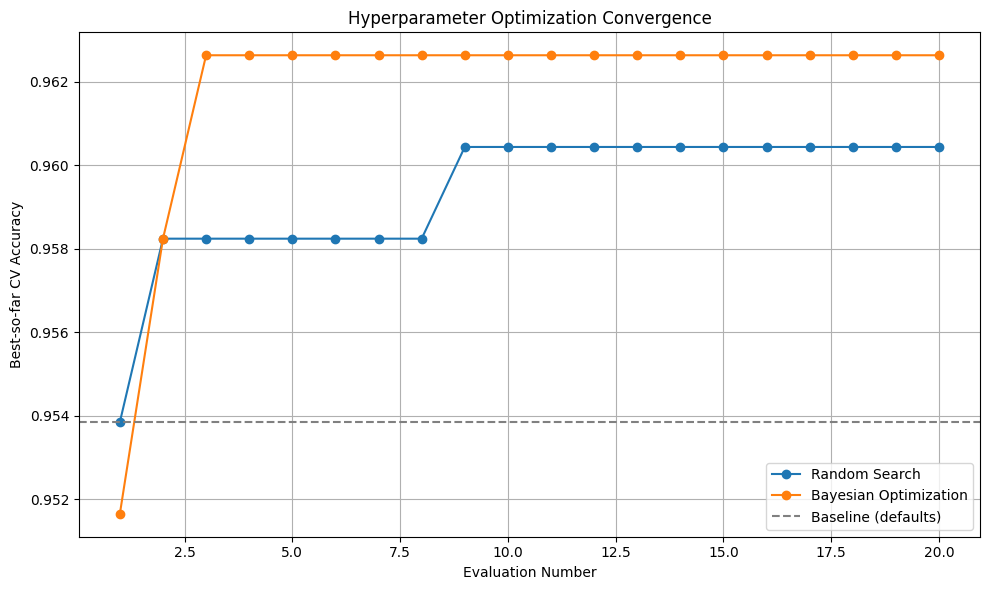

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(random_best_so_far) + 1),
    random_best_so_far,
    marker="o",
    label="Random Search"
)

plt.plot(
    range(1, len(bayesian_best_so_far) + 1),
    bayesian_best_so_far,
    marker="o",
    label="Bayesian Optimization"
)

plt.axhline(baseline_cv_score, color="gray", linestyle="--", label="Baseline (defaults)")

plt.xlabel("Evaluation Number")
plt.ylabel("Best-so-far CV Accuracy")
plt.title("Hyperparameter Optimization Convergence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 13. CONVERGENCE PLOT

In [ ]:
print("FINAL COMPARISON") 
print("=" * 50) 
print( f"Baseline CV: {baseline_cv_score:.4f}" ) 
print( f"Random Search CV: " f"{random_results['best_cv_score']:.4f}" ) 
print( f"Bayesian Optimization CV: " f"{bayesian_results['best_cv_score']:.4f}" ) 
print() 

print( f"Baseline Test: {baseline_test_score:.4f}" ) 
print( f"Random Search Test: {random_test_score:.4f}" ) 
print( f"Bayesian Optimization Test:{bayesian_test_score:.4f}" ) 

print() 
print( f"Random Search Runtime: " f"{random_results['runtime']:.2f}s" ) 
print( f"Bayesian Runtime: " f"{bayesian_results['runtime']:.2f}s" )

FINAL COMPARISON
Baseline CV: 0.9538
Random Search CV: 0.9604
Bayesian Optimization CV: 0.9626

Baseline Test: 0.9561
Random Search Test: 0.9561
Bayesian Optimization Test:0.9474

Random Search Runtime: 77.82s
Bayesian Runtime: 98.66s
